In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from random import randint, random, sample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    classification_report
)

In [3]:
df_train = pd.read_csv("KDD_Train_Set2.csv")
df_test  = pd.read_csv("KDD_Test_Set2.csv")

In [4]:
df_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,service_whois,flag_OTH,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SH,label
0,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
1,-0.112481,-0.007390,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,1.217651,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,0.0
2,-0.112481,-0.007435,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
3,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,7.912287,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
4,12.607970,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,6.860279,-0.051047,-0.030936,-0.044839,-0.048183,1.0


In [5]:
df_test.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,service_whois,flag_OTH,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SH,label
0,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
1,-0.112481,-0.007433,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
2,2.446564,-0.007409,-0.004586,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,0.0
3,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0
4,-0.112481,-0.007246,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183,1.0


In [6]:
x_train,y_train = df_train.iloc[:,:-1], df_train["label"]
x_test,y_test = df_train.iloc[:,:-1], df_train["label"]

In [7]:
x_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,service_vmnet,service_whois,flag_OTH,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SH
0,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.066812,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183
1,-0.112481,-0.007390,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,1.217651,-0.011473,...,-0.066812,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183
2,-0.112481,-0.007435,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.066812,-0.070427,-0.018351,-0.126386,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183
3,-0.112481,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.066812,-0.070427,-0.018351,7.912287,-0.026599,-0.145767,-0.051047,-0.030936,-0.044839,-0.048183
4,12.607970,-0.007436,-0.004614,-0.01468,-0.085488,-0.010403,-0.094071,-0.059832,-0.821254,-0.011473,...,-0.066812,-0.070427,-0.018351,-0.126386,-0.026599,6.860279,-0.051047,-0.030936,-0.044839,-0.048183


In [8]:
y_train.head()

0    1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: label, dtype: float64

# parameters for the genetic algorithm

In [15]:
populationSize = 20 
numGenerations = 15
crossoverRate = 0.8 # it means 80% of the selected parent pairs will undergo crossover to produce offspring.
mutationRate = 0.1  # the probability of performing mutation on an individual’s genes to introduce small, random changes.
useElitism = True   # the best solution(s) from the current generation are guaranteed to survive and appear in the next generation.

# initialize lists for storing data for visualization

In [17]:
best_fitness_history = []
feature_size_history = []

In [11]:
numFeatures = x_train.shape[1]

# 2 => range (0 or 1)
# size=(populationSize, numFeatures) => create 2D array (20 * 102)
population = np.random.randint(2, size=(populationSize, numFeatures))

# fitness function to evaluate a subset of features. 

In [12]:
def fitnessFunction(individual):

    # use only the selected features
    selectedFeatures = []

    for i in range(numFeatures):
        if individual[i] == 1:
            selectedFeatures.append(i)

    if not selectedFeatures:  # if no features selected, assign 0 fitness
        return 0

    # train a DecisionTreeClassifier with the selected features
    model = DecisionTreeClassifier()
    model.fit(x_train.iloc[:, selectedFeatures], y_train)
    predictions = model.predict(x_test.iloc[:, selectedFeatures])

    # use F1 score as the fitness metric for the selected features
    return f1_score(y_test, predictions)

# GA operations: selection, crossover, mutation, elitism
def selectParents(population, fitness):

    # tournament selection with 3 individuals
    parents = []
    for _ in range(2): # _ indicating that the value of the loop variable is not used in the loop body.
        # k = 3 => Randomly Select 3 Individuals.
        tournament = sample(range(len(population)), k=3) # sample() => ensures that the same individual is not selected more than once in the tournament.

        tournamentFitness = []
        for i in tournament:
            tournamentFitness.append(fitness[i])

        bestIndividual = tournament[np.argmax(tournamentFitness)] # Finds the index of the maximum fitness in tournamentFitness
        
        parents.append(population[bestIndividual])
    return parents[0], parents[1]

# single-point crossover
def crossover(parent1, parent2):
    if random() < crossoverRate: # random(): Generates a random float between 0 and 1.
        point = randint(1, numFeatures - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2
    return parent1, parent2

# mutation by flipping a bit
def adaptive_mutation(individual, generation, max_generations, mutationRate):
    # adaptive mutation rate that goes down over generations
    # in early generations: more exploration, higher mutation
    # in later generations: more exploitation, lower mutation
    adaptive_rate = mutationRate * (1 - generation / max_generations)
    
    # mutate individual with adaptive probability
    for i in range(len(individual)):
        if random() < adaptive_rate:
            individual[i] = 1 - individual[i]  # Bit flip
    
    # make sure at least one feature is always selected
    if np.sum(individual) == 0:
        individual[np.random.randint(len(individual))] = 1
    
    return individual

# adaptive mutation
def mutate(individual, generation, max_generations):
    return adaptive_mutation(individual, generation, max_generations, mutationRate)

# run GA

In [13]:
for generation in range(numGenerations):

    # evaluate fitness of each individual in the population
    fitness = []
    for individual in population:
        fitnessValue = fitnessFunction(individual)
        fitness.append(fitnessValue)

    fitness = np.array(fitness)

    # track best fitness
    best_fitness = np.max(fitness)
    best_fitness_history.append(best_fitness)

    # track feature size distribution
    feature_sizes = np.sum(population, axis=1) #  adds up the values along a specified row (axis)
    feature_size_history.append(feature_sizes)
    
    # elitism: keep the best individual
    if useElitism:
        best_index = np.argmax(fitness)
        best_individual = population[best_index].copy()
        best_fitness = fitness[best_index]
    
    # generate new population
    new_population = []
    while len(new_population) < populationSize:
        parent1, parent2 = selectParents(population, fitness)
        child1, child2 = crossover(parent1, parent2)
        
        # pass generation information to mutation
        child1 = mutate(child1, generation, numGenerations)
        child2 = mutate(child2, generation, numGenerations)
        
        new_population.extend([child1, child2])#  add new offspring (children)
    
    # ensure population size remains constant
    new_population = new_population[:populationSize]
    population = np.array(new_population)
    
    # replace worst individual with the best (elitism)
    if useElitism:        
        fitnessValues = []
        for ind in population:
            fitnessValue = fitnessFunction(ind)
            fitnessValues.append(fitnessValue)

        worst_index = np.argmin(fitnessValues)

        population[worst_index] = best_individual

    # print best fitness in each generation
    print(f"Generation {generation + 1}, Best F1 score: {best_fitness}")

Generation 1, Best F1 score: 0.998871144169766
Generation 2, Best F1 score: 0.998871144169766
Generation 3, Best F1 score: 0.9988884901845806
Generation 4, Best F1 score: 0.9990111572959965
Generation 5, Best F1 score: 0.9990111572959965
Generation 6, Best F1 score: 0.9990811477776903
Generation 7, Best F1 score: 0.9990811477776903
Generation 8, Best F1 score: 0.9990811477776903
Generation 9, Best F1 score: 0.9990811477776903
Generation 10, Best F1 score: 0.9990899067154383
Generation 11, Best F1 score: 0.9990899067154383
Generation 12, Best F1 score: 0.9990899067154383
Generation 13, Best F1 score: 0.9990899067154383
Generation 14, Best F1 score: 0.9990899067154383
Generation 15, Best F1 score: 0.9990899067154383


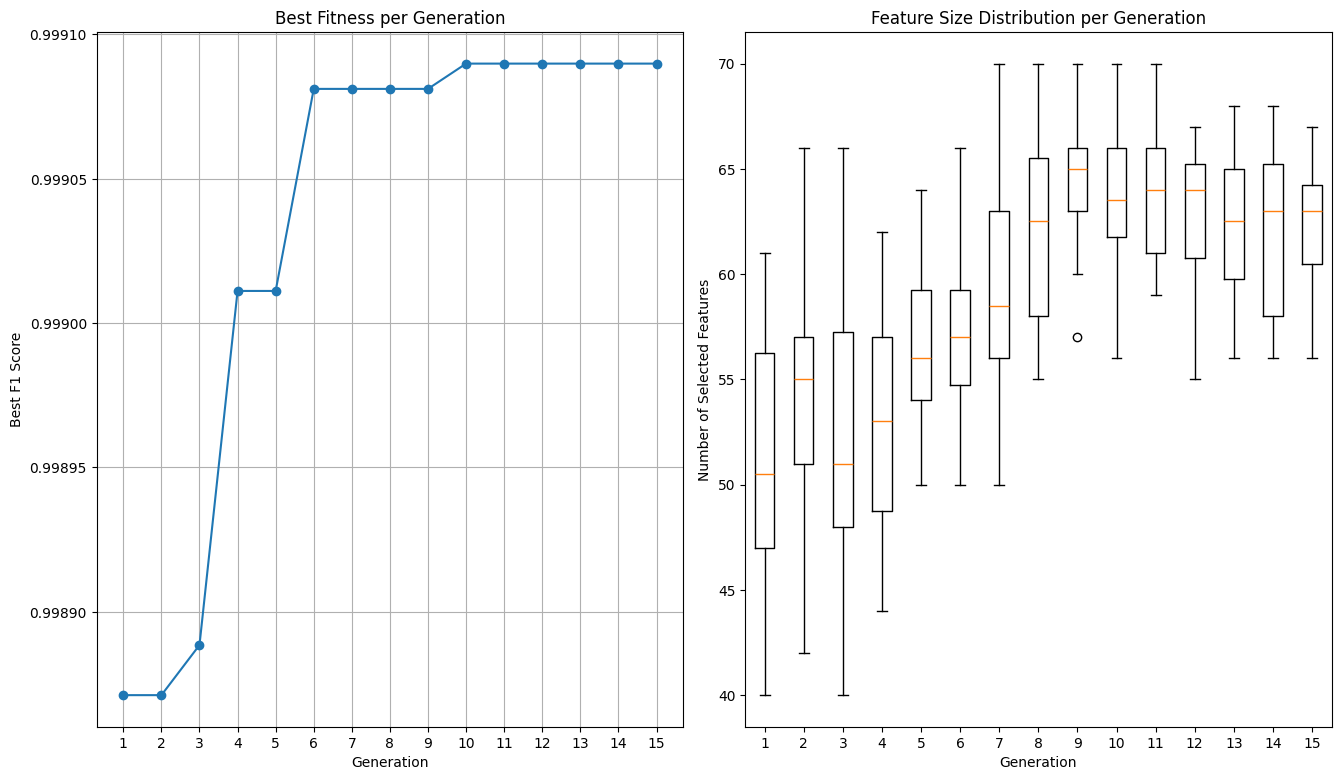

In [14]:
# visualization plots
plt.figure(figsize=(20, 15)) # Create a new figure with width = 20 and height = 15


# generation vs best fitness (f1-score) plot

plt.subplot(2, 3, 1) # no of rows=2, cols=3, position = 1
plt.plot(range(1, numGenerations + 1), best_fitness_history, marker='o')
plt.title('Best Fitness per Generation')
plt.xlabel('Generation')
plt.ylabel('Best F1 Score')
plt.xticks(range(1, numGenerations + 1))
plt.grid(True)


# feature size distribution boxplot
plt.subplot(2, 3, 2)
feature_size_matrix = np.array(feature_size_history)
plt.boxplot(feature_size_matrix.T)
plt.title('Feature Size Distribution per Generation')
plt.xlabel('Generation')
plt.ylabel('Number of Selected Features')
plt.xticks(range(1, numGenerations + 1))

plt.tight_layout()
plt.show()

# after GA, select the best features

In [19]:
final_fitness = []
for individual in population:
    fitness_value = fitnessFunction(individual)
    final_fitness.append(fitness_value)

final_fitness = np.array(final_fitness)

best_solution = population[np.argmax(final_fitness)]

selected_features = []
for i, bit in enumerate(best_solution):
    if bit == 1:
        selected_features.append(i)


print("Selected Feature Indices:", selected_features)

Selected Feature Indices: [0, 1, 2, 3, 6, 9, 10, 11, 12, 13, 16, 17, 18, 20, 21, 23, 24, 25, 26, 28, 31, 32, 34, 35, 36, 38, 40, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 57, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 77, 81, 83, 84, 85, 88, 89, 92, 96, 98, 99]


# Convert selected feature indices to column names if needed

In [25]:
if isinstance(selected_features[0], int):  # If features are indices
    selected_features = x_train.columns[selected_features]

X_train_selected =x_train[selected_features]
X_test_selected = x_test[selected_features]

# Initialize models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Store metrics for visualization
metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Append metrics
    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1-Score'].append(f1)
    
    print(f"Performance of {model_name}:")
    print(classification_report(y_test, y_pred)) 

Performance of Decision Tree:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     61642
         1.0       1.00      1.00      1.00     57170

    accuracy                           1.00    118812
   macro avg       1.00      1.00      1.00    118812
weighted avg       1.00      1.00      1.00    118812

Performance of KNN:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     61642
         1.0       0.99      0.99      0.99     57170

    accuracy                           0.99    118812
   macro avg       0.99      0.99      0.99    118812
weighted avg       0.99      0.99      0.99    118812



# Visualization of model performance

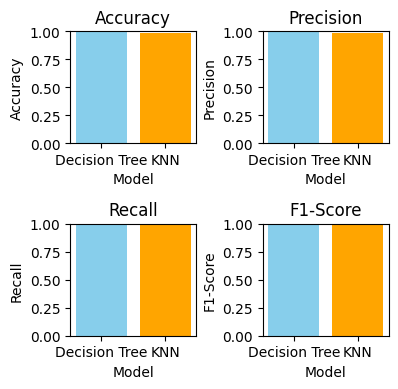

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(4, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metric_names):
    ax[i // 2, i % 2].bar(metrics['Model'], metrics[metric], color=['skyblue', 'orange'])
    ax[i // 2, i % 2].set_title(metric)
    ax[i // 2, i % 2].set_ylim(0, 1)
    ax[i // 2, i % 2].set_ylabel(metric)
    ax[i // 2, i % 2].set_xlabel('Model')

plt.tight_layout()
plt.show()